# ResNet50: frozen y fine tuning parcial

Objetivo: entrenar ResNet50 sobre `Plant_disease_recognition_dataset` en dos estrategias de transferencia y comparar el resultado contra el baseline CNN ya calculado en `Baseline_basico.ipynb`.

Flujo:
1. ResNet50 con backbone congelado y solo `fc` entrenable.
2. ResNet50 con fine tuning parcial de `layer3`, `layer4` y `fc`, inicializado desde el mejor modelo frozen.
3. Comparacion baseline vs frozen vs fine tuning parcial usando metricas de test.

## 1. Imports y configuracion

In [1]:
from pathlib import Path
import copy
import random
import time

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import ResNet50_Weights, resnet50

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

SEED = 42


def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 2. Rutas del dataset

In [2]:
# Este bloque funciona si el notebook se ejecuta desde Project/ o desde la raiz del repo.
DATASET_ROOT = Path("Plant_disease_recognition_dataset")
if not DATASET_ROOT.exists():
    DATASET_ROOT = Path("Project") / "Plant_disease_recognition_dataset"

SPLIT_DIRS = {
    "train": DATASET_ROOT / "Train" / "Train",
    "validation": DATASET_ROOT / "Validation" / "Validation",
    "test": DATASET_ROOT / "Test" / "Test",
}

for split_name, split_path in SPLIT_DIRS.items():
    if not split_path.exists():
        raise FileNotFoundError(f"No se encontro la carpeta de {split_name}: {split_path}")
    print(f"{split_name}: {split_path}")

train: Plant_disease_recognition_dataset/Train/Train
validation: Plant_disease_recognition_dataset/Validation/Validation
test: Plant_disease_recognition_dataset/Test/Test


## 3. Revision del dataset

In [3]:
records = []

for split_name, split_path in SPLIT_DIRS.items():
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        for image_path in sorted(class_dir.iterdir()):
            if not image_path.is_file():
                continue

            with Image.open(image_path) as img:
                records.append(
                    {
                        "split": split_name,
                        "class": class_dir.name,
                        "path": str(image_path),
                        "extension": image_path.suffix.lower(),
                        "format": img.format,
                        "mode": img.mode,
                        "width": img.width,
                        "height": img.height,
                    }
                )

metadata = pd.DataFrame(records)

print(f"Imagenes totales: {len(metadata)}")
display(metadata.head())

Imagenes totales: 1532


,split,class,path,extension,format,mode,width,height
0,train,Healthy,Plant_disease_recognition_dataset/Train/Train/...,.jpg,JPEG,RGB,4000,3000
1,train,Healthy,Plant_disease_recognition_dataset/Train/Train/...,.jpg,JPEG,RGB,4000,2672
2,train,Healthy,Plant_disease_recognition_dataset/Train/Train/...,.jpg,JPEG,RGB,4000,2672
3,train,Healthy,Plant_disease_recognition_dataset/Train/Train/...,.jpg,JPEG,RGB,4000,2672
4,train,Healthy,Plant_disease_recognition_dataset/Train/Train/...,.jpg,JPEG,RGB,4000,2672


Imagenes por split:


,total
split,
test,150
train,1322
validation,60


Balance por clase:


class,Healthy,Powdery,Rust
split,,,
test,50,50,50
train,458,430,434
validation,20,20,20


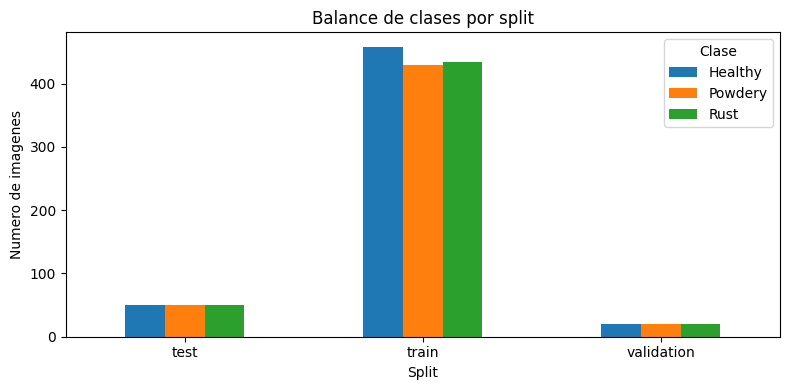

In [4]:
class_counts = metadata.groupby(["split", "class"]).size().unstack(fill_value=0)
split_counts = metadata.groupby("split").size().rename("total")

print("Imagenes por split:")
display(split_counts.to_frame())

print("Balance por clase:")
display(class_counts)

ax = class_counts.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Balance de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Numero de imagenes")
ax.legend(title="Clase")
plt.tight_layout()
plt.show()

In [5]:
print("Formatos de archivo:")
display(metadata.groupby(["split", "extension", "format", "mode"]).size().rename("count").reset_index())

print("Tamanos mas frecuentes:")
display(
    metadata.assign(size=metadata["width"].astype(str) + "x" + metadata["height"].astype(str))
    .groupby(["split", "size"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["split", "count"], ascending=[True, False])
    .groupby("split")
    .head(10)
)

display(metadata[["width", "height"]].describe())

Formatos de archivo:


,split,extension,format,mode,count
0,test,.jpg,JPEG,RGB,150
1,train,.jpg,JPEG,RGB,1322
2,validation,.jpg,JPEG,RGB,60


Tamanos mas frecuentes:


,split,size,count
2,test,4000x2672,111
0,test,2592x1728,17
5,test,5184x3456,10
3,test,4000x3000,6
4,test,4608x3456,5
1,test,3901x2607,1
8,train,4000x2672,976
7,train,2592x1728,105
12,train,5184x3456,82
9,train,4000x3000,80


,width,height
count,1532.000000,1532.000000
mean,3986.058747,2702.447781
std,521.635395,385.260266
min,2421.000000,1728.000000
25%,4000.000000,2672.000000
50%,4000.000000,2672.000000
75%,4000.000000,2672.000000
max,5184.000000,3456.000000


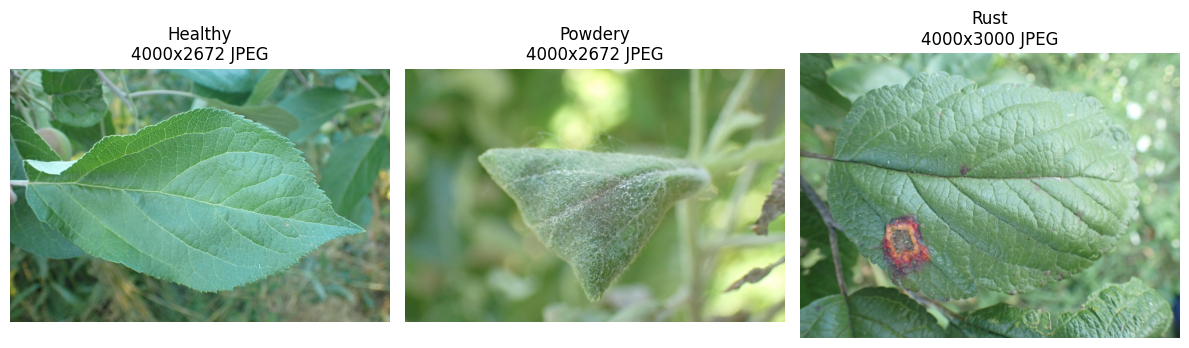

In [6]:
# Una imagen de ejemplo por clase en el split de entrenamiento.
sample_images = metadata[metadata["split"] == "train"].groupby("class").sample(n=1, random_state=SEED)

fig, axes = plt.subplots(1, len(sample_images), figsize=(12, 4))
if len(sample_images) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_images.iterrows()):
    with Image.open(row["path"]) as img:
        ax.imshow(img)
    ax.set_title(f"{row['class']}\n{row['width']}x{row['height']} {row['format']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Preparacion de datos para ResNet50

ResNet50 preentrenada en ImageNet espera entradas de `224x224` normalizadas con media y desviacion estandar de ImageNet. El baseline usa su propio preprocesamiento simple; aqui se usa el preprocesamiento adecuado para transferencia.

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32 if device.type == "cuda" else 8
NUM_WORKERS = 0

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.70, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

train_dataset = datasets.ImageFolder(root=SPLIT_DIRS["train"], transform=train_transform)
val_dataset = datasets.ImageFolder(root=SPLIT_DIRS["validation"], transform=eval_transform)
test_dataset = datasets.ImageFolder(root=SPLIT_DIRS["test"], transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Clases:", class_names)
print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Batch size: {BATCH_SIZE}")

Clases: ['Healthy', 'Powdery', 'Rust']
Train: 1322 | Validation: 60 | Test: 150
Batch size: 32


In [8]:
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    generator=generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

images, labels = next(iter(train_loader))
print("Batch de imagenes:", images.shape)
print("Batch de etiquetas:", labels.shape)

Batch de imagenes: torch.Size([32, 3, 224, 224])
Batch de etiquetas: torch.Size([32])


## 5. Metricas del baseline

Estas metricas vienen de `Baseline_basico.ipynb`, donde se entreno una CNN pequena desde cero durante 8 epocas.

In [9]:
baseline_metrics = {
    "modelo": "Baseline CNN",
    "estrategia": "desde cero",
    "capas_entrenables": "toda la CNN",
    "test_loss": 0.865673,
    "test_accuracy": 0.680000,
    "precision_macro": 0.797395,
    "recall_macro": 0.680000,
    "f1_macro": 0.668928,
    "precision_weighted": 0.797395,
    "recall_weighted": 0.680000,
    "f1_weighted": 0.668928,
}

baseline_df = pd.DataFrame([baseline_metrics])
display(baseline_df)

,modelo,estrategia,capas_entrenables,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Baseline CNN,desde cero,toda la CNN,0.865673,0.68,0.797395,0.68,0.668928,0.797395,0.68,0.668928


## 6. Funciones de entrenamiento y evaluacion

In [10]:
def build_resnet50(num_classes: int) -> nn.Module:
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def freeze_all_but_fc(model: nn.Module) -> nn.Module:
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
    return model


def unfreeze_layer3_layer4_fc(model: nn.Module) -> nn.Module:
    for param in model.parameters():
        param.requires_grad = False
    for layer_name in ["layer3", "layer4", "fc"]:
        for param in getattr(model, layer_name).parameters():
            param.requires_grad = True
    return model


def parameter_summary(model: nn.Module) -> pd.DataFrame:
    rows = []
    for name, module in model.named_children():
        total = sum(p.numel() for p in module.parameters())
        trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        rows.append(
            {
                "bloque": name,
                "parametros": total,
                "entrenables": trainable,
                "congelados": total - trainable,
            }
        )
    return pd.DataFrame(rows)


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += batch_size

    return total_loss / total, correct / total


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs: int, model_name: str):
    history = []
    best_val_acc = -np.inf
    best_state = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        history.append(
            {
                "modelo": model_name,
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "best_val_accuracy": best_val_acc,
            }
        )

        print(
            f"{model_name} | Epoch {epoch:02d}/{epochs} | "
            f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f} | "
            f"best val acc: {best_val_acc:.4f}"
        )

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    elapsed_min = (time.time() - start_time) / 60
    print(f"Mejor validation accuracy de {model_name}: {best_val_acc:.4f} ({elapsed_min:.1f} min)")
    return model, history_df

In [11]:
@torch.no_grad()
def predict(model, dataloader, criterion):
    model.eval()
    y_true = []
    y_pred = []
    total_loss = 0.0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total += batch_size

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred), total_loss / total


def metrics_row(model_name, strategy, trainable_layers, y_true, y_pred, test_loss):
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "modelo": model_name,
        "estrategia": strategy,
        "capas_entrenables": trainable_layers,
        "test_loss": test_loss,
        "test_accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


def plot_history(history_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
    axes[0].set_title(f"Perdida - {title}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="validation")
    axes[1].set_title(f"Accuracy - {title}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 7. ResNet50 frozen

Se carga ResNet50 preentrenada en ImageNet, se congela todo el backbone y se entrena solamente la capa final `fc` adaptada a las 3 clases del dataset.

Resumen de parametros - ResNet50 frozen


,bloque,parametros,entrenables,congelados
0,conv1,9408,0,9408
1,bn1,128,0,128
2,relu,0,0,0
3,maxpool,0,0,0
4,layer1,215808,0,215808
5,layer2,1219584,0,1219584
6,layer3,7098368,0,7098368
7,layer4,14964736,0,14964736
8,avgpool,0,0,0
9,fc,6147,6147,0


ResNet50 frozen | Epoch 01/8 | train loss: 0.6917 | train acc: 0.8480 | val loss: 0.3963 | val acc: 0.9333 | best val acc: 0.9333
ResNet50 frozen | Epoch 02/8 | train loss: 0.3750 | train acc: 0.9281 | val loss: 0.2701 | val acc: 0.9667 | best val acc: 0.9667
ResNet50 frozen | Epoch 03/8 | train loss: 0.2764 | train acc: 0.9539 | val loss: 0.2066 | val acc: 0.9667 | best val acc: 0.9667
ResNet50 frozen | Epoch 04/8 | train loss: 0.2144 | train acc: 0.9561 | val loss: 0.1657 | val acc: 0.9667 | best val acc: 0.9667
ResNet50 frozen | Epoch 05/8 | train loss: 0.1952 | train acc: 0.9599 | val loss: 0.1579 | val acc: 0.9833 | best val acc: 0.9833
ResNet50 frozen | Epoch 06/8 | train loss: 0.1658 | train acc: 0.9697 | val loss: 0.1325 | val acc: 0.9667 | best val acc: 0.9833
ResNet50 frozen | Epoch 07/8 | train loss: 0.1436 | train acc: 0.9697 | val loss: 0.1266 | val acc: 0.9667 | best val acc: 0.9833
ResNet50 frozen | Epoch 08/8 | train loss: 0.1358 | train acc: 0.9720 | val loss: 0.1133 |

,modelo,epoch,train_loss,train_accuracy,val_loss,val_accuracy,best_val_accuracy
0,ResNet50 frozen,1,0.691654,0.847958,0.396285,0.933333,0.933333
1,ResNet50 frozen,2,0.374986,0.928139,0.270086,0.966667,0.966667
2,ResNet50 frozen,3,0.276390,0.953858,0.206569,0.966667,0.966667
3,ResNet50 frozen,4,0.214410,0.956127,0.165682,0.966667,0.966667
4,ResNet50 frozen,5,0.195192,0.959909,0.157920,0.983333,0.983333
5,ResNet50 frozen,6,0.165833,0.969743,0.132517,0.966667,0.983333
6,ResNet50 frozen,7,0.143586,0.969743,0.126649,0.966667,0.983333
7,ResNet50 frozen,8,0.135773,0.972012,0.113282,0.983333,0.983333


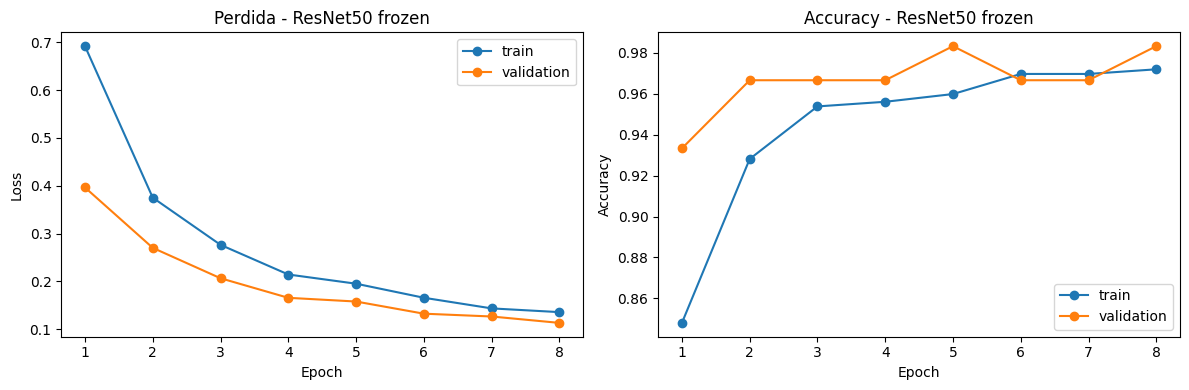

In [12]:
criterion = nn.CrossEntropyLoss()

seed_everything(SEED)
frozen_model = build_resnet50(num_classes)
frozen_model = freeze_all_but_fc(frozen_model).to(device)

print("Resumen de parametros - ResNet50 frozen")
display(parameter_summary(frozen_model))

optimizer_frozen = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, frozen_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

EPOCHS_FROZEN = 8
frozen_model, frozen_history = fit_model(
    frozen_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_frozen,
    epochs=EPOCHS_FROZEN,
    model_name="ResNet50 frozen",
)

display(frozen_history)
plot_history(frozen_history, "ResNet50 frozen")

In [13]:
y_true_frozen, y_pred_frozen, frozen_test_loss = predict(frozen_model, test_loader, criterion)

frozen_metrics = metrics_row(
    model_name="ResNet50",
    strategy="frozen",
    trainable_layers="fc",
    y_true=y_true_frozen,
    y_pred=y_pred_frozen,
    test_loss=frozen_test_loss,
)

display(pd.DataFrame([frozen_metrics]))
print(classification_report(y_true_frozen, y_pred_frozen, target_names=class_names, digits=4, zero_division=0))

,modelo,estrategia,capas_entrenables,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,ResNet50,frozen,fc,0.249493,0.953333,0.953803,0.953333,0.953317,0.953803,0.953333,0.953317


              precision    recall  f1-score   support

     Healthy     0.9231    0.9600    0.9412        50
     Powdery     0.9583    0.9200    0.9388        50
        Rust     0.9800    0.9800    0.9800        50

    accuracy                         0.9533       150
   macro avg     0.9538    0.9533    0.9533       150
weighted avg     0.9538    0.9533    0.9533       150



## 8. ResNet50 fine tuning parcial: layer3 + layer4 + fc

Este modelo parte del mejor estado obtenido en la etapa frozen. Luego se descongelan `layer3`, `layer4` y `fc`; el backbone usa una tasa de aprendizaje menor y la cabeza `fc` una tasa mayor.

Resumen de parametros - ResNet50 fine tuning parcial


,bloque,parametros,entrenables,congelados
0,conv1,9408,0,9408
1,bn1,128,0,128
2,relu,0,0,0
3,maxpool,0,0,0
4,layer1,215808,0,215808
5,layer2,1219584,0,1219584
6,layer3,7098368,7098368,0
7,layer4,14964736,14964736,0
8,avgpool,0,0,0
9,fc,6147,6147,0


ResNet50 layer3+layer4+fc | Epoch 01/8 | train loss: 0.1294 | train acc: 0.9735 | val loss: 0.0774 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+layer4+fc | Epoch 02/8 | train loss: 0.0793 | train acc: 0.9879 | val loss: 0.0680 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+layer4+fc | Epoch 03/8 | train loss: 0.0543 | train acc: 0.9902 | val loss: 0.0483 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+layer4+fc | Epoch 04/8 | train loss: 0.0374 | train acc: 0.9939 | val loss: 0.0415 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+layer4+fc | Epoch 05/8 | train loss: 0.0336 | train acc: 0.9932 | val loss: 0.0353 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+layer4+fc | Epoch 06/8 | train loss: 0.0287 | train acc: 0.9947 | val loss: 0.0344 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+layer4+fc | Epoch 07/8 | train loss: 0.0230 | train acc: 0.9962 | val loss: 0.0288 | val acc: 1.0000 | best val acc: 1.0000
ResNet50 layer3+laye

,modelo,epoch,train_loss,train_accuracy,val_loss,val_accuracy,best_val_accuracy
0,ResNet50 layer3+layer4+fc,1,0.129406,0.973525,0.077366,1.0,1.0
1,ResNet50 layer3+layer4+fc,2,0.079282,0.987897,0.068037,1.0,1.0
2,ResNet50 layer3+layer4+fc,3,0.054271,0.990166,0.048332,1.0,1.0
3,ResNet50 layer3+layer4+fc,4,0.037355,0.993949,0.041535,1.0,1.0
4,ResNet50 layer3+layer4+fc,5,0.033560,0.993192,0.035289,1.0,1.0
5,ResNet50 layer3+layer4+fc,6,0.028708,0.994705,0.034395,1.0,1.0
6,ResNet50 layer3+layer4+fc,7,0.023003,0.996218,0.028762,1.0,1.0
7,ResNet50 layer3+layer4+fc,8,0.017280,0.996974,0.023507,1.0,1.0


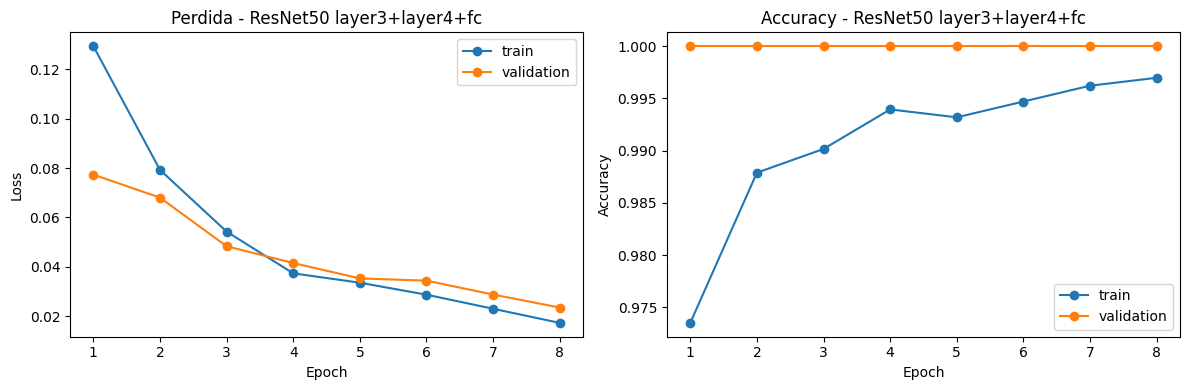

In [14]:
partial_model = copy.deepcopy(frozen_model)
partial_model = unfreeze_layer3_layer4_fc(partial_model).to(device)

print("Resumen de parametros - ResNet50 fine tuning parcial")
display(parameter_summary(partial_model))

optimizer_partial = torch.optim.AdamW(
    [
        {"params": partial_model.layer3.parameters(), "lr": 1e-5},
        {"params": partial_model.layer4.parameters(), "lr": 1e-5},
        {"params": partial_model.fc.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4,
)

EPOCHS_PARTIAL = 8
partial_model, partial_history = fit_model(
    partial_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_partial,
    epochs=EPOCHS_PARTIAL,
    model_name="ResNet50 layer3+layer4+fc",
)

display(partial_history)
plot_history(partial_history, "ResNet50 layer3+layer4+fc")

In [15]:
y_true_partial, y_pred_partial, partial_test_loss = predict(partial_model, test_loader, criterion)

partial_metrics = metrics_row(
    model_name="ResNet50",
    strategy="fine tuning parcial",
    trainable_layers="layer3 + layer4 + fc",
    y_true=y_true_partial,
    y_pred=y_pred_partial,
    test_loss=partial_test_loss,
)

display(pd.DataFrame([partial_metrics]))
print(classification_report(y_true_partial, y_pred_partial, target_names=class_names, digits=4, zero_division=0))

,modelo,estrategia,capas_entrenables,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,ResNet50,fine tuning parcial,layer3 + layer4 + fc,0.189315,0.96,0.962894,0.96,0.960137,0.962894,0.96,0.960137


              precision    recall  f1-score   support

     Healthy     0.9091    1.0000    0.9524        50
     Powdery     1.0000    0.9200    0.9583        50
        Rust     0.9796    0.9600    0.9697        50

    accuracy                         0.9600       150
   macro avg     0.9629    0.9600    0.9601       150
weighted avg     0.9629    0.9600    0.9601       150



## 9. Comparacion baseline vs frozen vs fine tuning parcial

In [16]:
comparison_df = pd.DataFrame([baseline_metrics, frozen_metrics, partial_metrics])
metric_cols = [
    "test_loss",
    "test_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
]

comparison_display = comparison_df.copy()
comparison_display[metric_cols] = comparison_display[metric_cols].round(4)
display(comparison_display)

best_by_accuracy = comparison_df.loc[comparison_df["test_accuracy"].idxmax()]
best_by_f1 = comparison_df.loc[comparison_df["f1_macro"].idxmax()]
print(f"Mejor accuracy test: {best_by_accuracy['modelo']} ({best_by_accuracy['estrategia']}) = {best_by_accuracy['test_accuracy']:.4f}")
print(f"Mejor F1 macro test: {best_by_f1['modelo']} ({best_by_f1['estrategia']}) = {best_by_f1['f1_macro']:.4f}")

,modelo,estrategia,capas_entrenables,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Baseline CNN,desde cero,toda la CNN,0.8657,0.6800,0.7974,0.6800,0.6689,0.7974,0.6800,0.6689
1,ResNet50,frozen,fc,0.2495,0.9533,0.9538,0.9533,0.9533,0.9538,0.9533,0.9533
2,ResNet50,fine tuning parcial,layer3 + layer4 + fc,0.1893,0.9600,0.9629,0.9600,0.9601,0.9629,0.9600,0.9601


Mejor accuracy test: ResNet50 (fine tuning parcial) = 0.9600
Mejor F1 macro test: ResNet50 (fine tuning parcial) = 0.9601


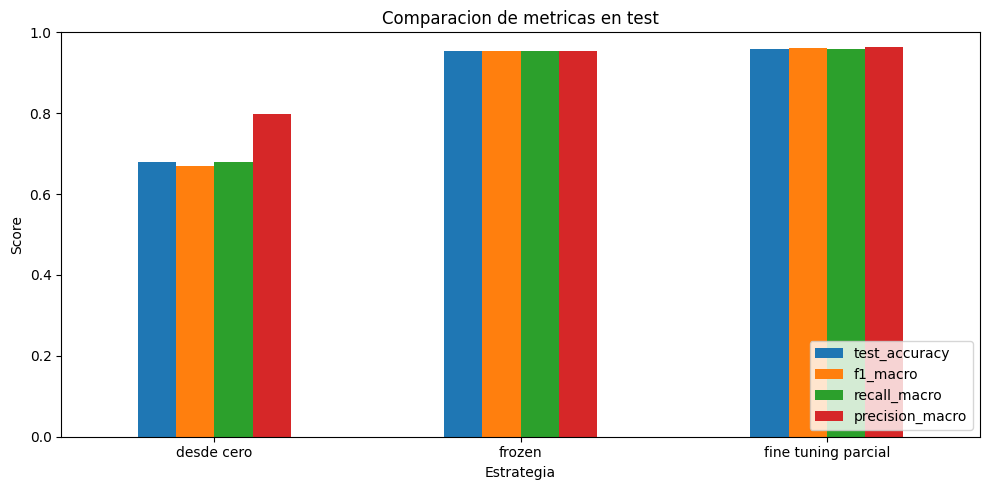

In [17]:
plot_df = comparison_df.set_index("estrategia")[["test_accuracy", "f1_macro", "recall_macro", "precision_macro"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0, 1)
ax.set_title("Comparacion de metricas en test")
ax.set_xlabel("Estrategia")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3260/717965473.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


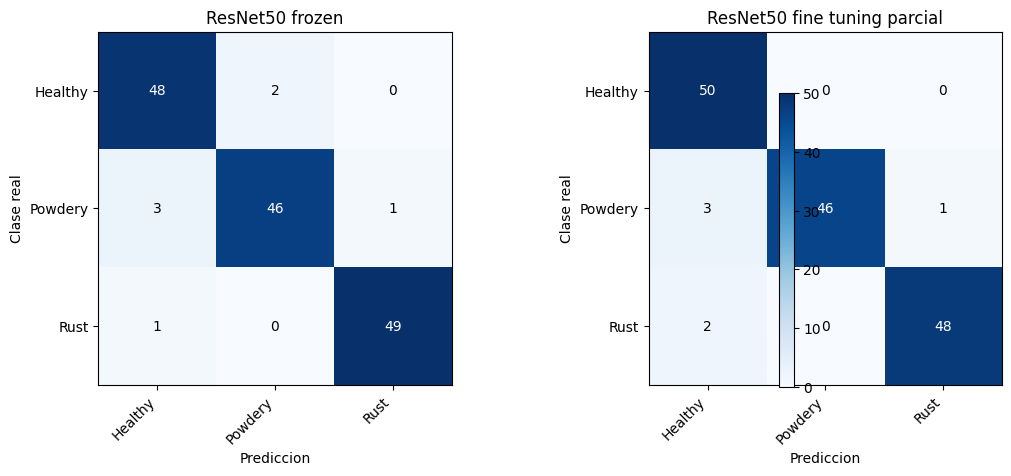

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_frozen, y_pred_frozen, "ResNet50 frozen"),
    (axes[1], y_true_partial, y_pred_partial, "ResNet50 fine tuning parcial"),
]:
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Clase real")
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    threshold = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            color = "white" if cm[i, j] > threshold else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
plt.tight_layout()
plt.show()

## 10. Lectura esperada

- Si `ResNet50 frozen` supera al baseline, la representacion preentrenada de ImageNet ya aporta informacion util aunque solo se entrene `fc`.
- Si el fine tuning parcial mejora al frozen, `layer3` y `layer4` se estan adaptando a patrones especificos de hojas sanas, polvo y roya.
- Si el fine tuning parcial empeora en validation o test, probablemente necesita menos epocas, menor learning rate o data augmentation mas conservador por el tamano pequeno del split de validation.